In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import re

In [3]:
df = pd.read_csv("dataset/spam.csv", encoding="latin-1")

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Shape: (5572, 5)

Columns: Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [4]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["v1"].value_counts())

print("\nClass percentage:")
print(df["v1"].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None

Missing values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Class distribution:
v1
ham     4825
spam     747
Name: count, dtype: int64

Class percentage:
v1
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [5]:
# Keep only the required columns
df = df[["v1", "v2"]]

# Rename columns for clarity
df.columns = ["label", "message"]

print("Columns after cleaning:")
print(df.columns)

print("\nShape after cleaning:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

Columns after cleaning:
Index(['label', 'message'], dtype='object')

Shape after cleaning:
(5572, 2)

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [6]:
# Display some messages containing non-ASCII characters
non_ascii = df[df["message"].apply(lambda x: any(ord(char) > 127 for char in x))]

print("Number of messages containing non-ASCII characters:", len(non_ascii))

print("\nSample messages:")
print(non_ascii["message"].head(20).to_string(index=False))

Number of messages containing non-ASCII characters: 481

Sample messages:
FreeMsg Hey there darling it's been 3 week's no...
WINNER!! As a valued network customer you have ...
URGENT! You have won a 1 week FREE membership i...
Fine if thatåÕs the way u feel. ThatåÕs the way...
England v Macedonia - dont miss the goals/team ...
 IÛ÷m going to try for 2 months ha ha only joking
So Ì_ pay first lar... Then when is da stock co...
Thanks for your subscription to Ringtone UK you...
Yup... Ok i go home look at the timings then i ...
As a valued customer, I am pleased to advise yo...
Urgent UR awarded a complimentary trip to EuroD...
Yeah do! DonÛ÷t stand to close tho- youÛ÷ll c...
Please call our customer service representative...
GENT! We are trying to contact you. Last weeken...
You are a winner U have been specially selected...
URGENT! Your Mobile No. was awarded å£2000 Bonu...
          ÌÏ predict wat time Ì_'ll finish buying?
Sunshine Quiz Wkly Q! Win a top Sony DVD player...
Got c...

In [8]:
df["message"] = df["message"].str.lower()

print(df["message"].head())

0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
3    u dun say so early hor... u c already then say...
4    nah i don't think he goes to usf, he lives aro...
Name: message, dtype: object


In [9]:
def clean_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

df["clean_message"] = df["message"].apply(clean_text)

print(df[["message", "clean_message"]].head())

                                             message  \
0  go until jurong point, crazy.. available only ...   
1                      ok lar... joking wif u oni...   
2  free entry in 2 a wkly comp to win fa cup fina...   
3  u dun say so early hor... u c already then say...   
4  nah i don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in 2 a wkly comp to win fa cup fina...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  


In [10]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df["clean_message"] = df["clean_message"].apply(remove_stopwords)

print(df[["message", "clean_message"]].head())

                                             message  \
0  go until jurong point, crazy.. available only ...   
1                      ok lar... joking wif u oni...   
2  free entry in 2 a wkly comp to win fa cup fina...   
3  u dun say so early hor... u c already then say...   
4  nah i don't think he goes to usf, he lives aro...   

                                       clean_message  
0  jurong point crazy available bugis n great wor...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                        u dun say early hor u c say  
4                      nah dont think goes usf lives  


## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features.

It gives higher importance to words that are important within a message but less common across the entire collection of messages.

TF-IDF allows machine-learning algorithms to work with text data by representing each message as a numerical vector.

In [11]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["clean_message"])

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (5572, 9174)


In [12]:
y = df["label"].map({"ham": 0, "spam": 1})

print(y.head())
print("\nTarget distribution:")
print(y.value_counts())

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64

Target distribution:
label
0    4825
1     747
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (4457, 9174)
Testing data: (1115, 9174)
Training labels: (4457,)
Testing labels: (1115,)


In [14]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [15]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes Performance")
print("-----------------------------------")
print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

Multinomial Naive Bayes Performance
-----------------------------------
Accuracy : 0.9623318385650225
Precision: 1.0
Recall   : 0.7181208053691275
F1 Score : 0.8359375


In [16]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Ham", "Spam"]
))


Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



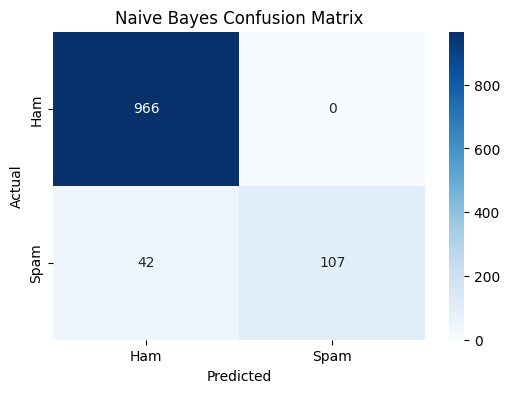

In [17]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [19]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression predictions:")
print(y_pred_lr[:10])

Logistic Regression predictions:
[0 0 0 1 0 0 0 0 0 0]


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Logistic Regression Performance
--------------------------------
Accuracy : 0.947085201793722
Precision: 0.9891304347826086
Recall   : 0.610738255033557
F1 Score : 0.7551867219917012


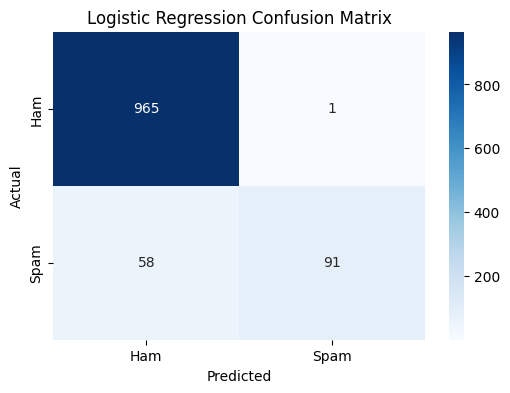

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Comparison

| Metric | Multinomial Naive Bayes | Logistic Regression |
|--------|--------------------------|---------------------|
| Accuracy | 96.23% | 94.71% |
| Precision | 100.00% | 98.91% |
| Recall | 71.81% | 61.07% |
| F1 Score | 83.59% | 75.52% |

### Conclusion

Based on the test-set results, Multinomial Naive Bayes achieved higher
accuracy, precision, recall, and F1-score than Logistic Regression.

Therefore, Multinomial Naive Bayes was selected as the model used for
the final spam classification in this project.

Recall is particularly important in spam detection because a false
negative means that an actual spam message is classified as ham.

## Why is Recall Important for Spam Detection?

Recall is important because it measures how many actual spam messages are correctly identified.

A false negative occurs when a spam message is incorrectly classified as a ham message.

In spam detection, missing a spam message can be undesirable because the spam message may reach the user's inbox.

Therefore, a high recall helps the model detect a larger proportion of actual spam messages.

For this dataset:

- Naive Bayes Recall = 71.81%
- Logistic Regression Recall = 61.07%

Therefore, Naive Bayes detected a larger proportion of the actual spam messages in the test set.

In [23]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt